# Tratamento da Unidade Movel Madureira

Este notebook organiza o tratamento horário da Unidade Móvel `Madureira` em quatro blocos simples:

1. padronizar o calendário horário;
2. interpolar apenas lacunas internas curtas;
3. validar o impacto do tratamento.

## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Carregamento da base da Unidade Móvel

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da Unidade Móvel para evitar problemas de codificação e isolamos apenas os registros da Unidade Móvel `Madureira`.

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_m_madureira = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL MADUREIRA"].copy()

df_m_madureira["data"] = pd.to_datetime(df_m_madureira["data"])
df_m_madureira = df_m_madureira.sort_values("data").reset_index(drop=True)
df_m_madureira = df_m_madureira.drop_duplicates(subset="data", keep="first")
df_m_madureira = df_m_madureira.set_index("data").sort_index().copy()

print("Dimensoes da base da Unidade Movel Madureira:", df_m_madureira.shape)
display(df_m_madureira.head())

Dimensoes da base da Unidade Movel Madureira: (3490, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2014-01-14 10:30:00,UNIDADE MOVEL MADUREIRA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0,-22.865555,-43.343363
2014-01-14 11:30:00,UNIDADE MOVEL MADUREIRA,0.0,33.93,50.43,19.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.865555,-43.343363
2014-01-14 12:30:00,UNIDADE MOVEL MADUREIRA,0.0,35.38,43.70,NaN,NaN,0.38,NaN,NaN,NaN,NaN,50.0,-22.865555,-43.343363
2014-01-14 13:30:00,UNIDADE MOVEL MADUREIRA,0.0,36.30,40.38,NaN,NaN,0.18,NaN,NaN,112.89,NaN,13.0,-22.865555,-43.343363
2014-01-14 14:30:00,UNIDADE MOVEL MADUREIRA,0.0,36.52,38.37,16.68,NaN,NaN,NaN,NaN,130.70,NaN,12.0,-22.865555,-43.343363


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de missing antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.

In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_m_madureira, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
no,3490,100.00,0
no2,3490,100.00,0
nox,3490,100.00,0
pm10,3490,100.00,0
pm2_5,522,14.96,2968
so2,489,14.01,3001
co,479,13.72,3011
o3,348,9.97,3142
temp,318,9.11,3172
ur,308,8.83,3182


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- interpolar apenas lacunas internas de até `4` horas consecutivas;
- não extrapolar bordas da série;
- não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.

In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_m_madureira_tratado = df_m_madureira.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_m_madureira[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_m_madureira_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"

    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_m_madureira_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
2,so2,interpolate_time,489,337,152
8,co,interpolate_time,479,356,123
3,pm2_5,interpolate_time,522,435,87
7,o3,interpolate_time,348,288,60
6,temp,interpolate_time,318,276,42
5,ur,interpolate_time,308,267,41
0,no,interpolate_time,3490,3490,0
1,no2,interpolate_time,3490,3490,0
4,nox,interpolate_time,3490,3490,0
9,pm10,interpolate_time,3490,3490,0


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- redução do missing por variável;
- estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir uma parte das lacunas sem alterar de forma relevante o comportamento geral das séries.

Total de valores imputados: 505


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
so2,489,14.01,337,9.66,152,31.08
co,479,13.72,356,10.20,123,25.68
pm2_5,522,14.96,435,12.46,87,16.67
o3,348,9.97,288,8.25,60,17.24
temp,318,9.11,276,7.91,42,13.21
ur,308,8.83,267,7.65,41,13.31
no,3490,100.00,3490,100.00,0,0.00
nox,3490,100.00,3490,100.00,0,0.00
no2,3490,100.00,3490,100.00,0,0.00
pm10,3490,100.00,3490,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
so2,6.248024,3.390,7.984371,6.207014,3.370,7.912893,-0.041010,-0.071478
pm2_5,20.017183,16.000,15.510177,19.831260,16.000,15.448312,-0.185923,-0.061865
ur,66.070299,68.050,17.674880,66.036141,67.870,17.615224,-0.034158,-0.059655
temp,25.235299,24.180,5.080836,25.261733,24.250,5.067888,0.026434,-0.012948
o3,24.381292,12.785,30.799583,24.667406,13.055,30.807019,0.286114,0.007435
co,0.492338,0.270,0.571366,0.494426,0.270,0.569068,0.002088,-0.002298
chuva,0.092926,0.000,1.454682,0.092926,0.000,1.454682,0.000000,0.000000


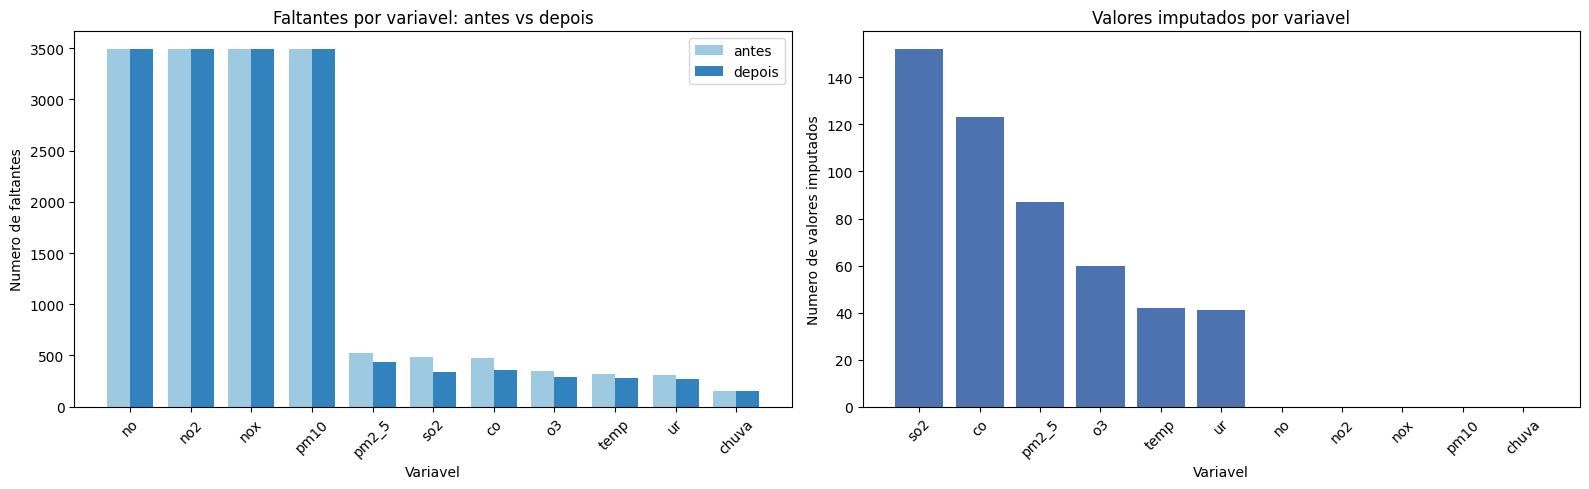

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_m_madureira_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_m_madureira[variavel].notna().any() or df_m_madureira_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_m_madureira, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_m_madureira_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Salvamento da base tratada

Por fim, salvamos a Unidade Movel `Madureira`:

- Série diária agregada (média para as variáveis e soma diária para `chuva`).

Essa saída já ficam prontas para reutilização nas próximas etapas da pipeline.


In [7]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

# Saída diária agregada:
# - média para a maior parte das variáveis
# - soma para chuva (preservando NaN quando o dia inteiro está faltante)

def somar_chuva_diaria(serie: pd.Series) -> float:
    return serie.sum(min_count=1)

agregacoes_diarias = {
    variavel: "mean"
    for variavel in variaveis_ambientais
    if variavel != "chuva"
}
agregacoes_diarias["chuva"] = somar_chuva_diaria

df_um_madureira_diario = (
    df_m_madureira_tratado[variaveis_ambientais]
    .resample("D")
    .agg(agregacoes_diarias)
)

df_um_madureira_diario_saida = df_um_madureira_diario.reset_index()
output_csv_diario_path = output_dir / "um_madureira_tratado_diario.csv"
df_um_madureira_diario_saida.to_csv(output_csv_diario_path, index=False, encoding="utf-8")

print(f"Arquivo diario salvo em: {output_csv_diario_path}")
display(df_um_madureira_diario_saida.head())


Arquivo diario salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\um_madureira_tratado_diario.csv


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva
0,2014-01-14,NaN,NaN,9.271538,20.285714,NaN,48.144615,33.905769,54.883636,0.244167,NaN,0.0
1,2014-01-15,NaN,NaN,13.656875,17.281250,NaN,60.772500,31.313750,59.355625,0.223750,NaN,0.0
2,2014-01-16,NaN,NaN,13.302667,18.656250,NaN,62.384000,29.534000,70.777333,0.213333,NaN,82.0
3,2014-01-17,NaN,NaN,7.901765,14.000000,NaN,70.462941,26.733529,49.558235,0.321765,NaN,0.0
4,2014-01-18,NaN,NaN,4.993750,9.104167,NaN,70.070000,26.629167,40.174583,0.239583,NaN,0.0


## Resumo interpretativo do tratamento

O tratamento aplicado na `Unidade Móvel Madureira` manteve a estratégia conservadora de interpolação temporal em lacunas curtas (até `4` horas) e melhorou a completude sem alterar, de forma relevante, o comportamento geral das séries. No total, foram imputados `505` valores, com maior contribuição em `so2` (`152`), `co` (`123`), `pm2_5` (`87`) e `o3` (`60`), além de ganhos em `temp` (`42`) e `ur` (`41`).

As reduções de dados faltantes ocorreram principalmente em `so2` (`14,01%` para `9,66%`), `co` (`13,72%` para `10,20%`), `pm2_5` (`14,96%` para `12,46%`) e `o3` (`9,97%` para `8,25%`). Também houve melhora em `temp` (`9,11%` para `7,91%`) e `ur` (`8,83%` para `7,65%`).

Em contrapartida, `no`, `no2`, `nox` e `pm10` permaneceram com `100%` de dados faltantes, indicando ausência estrutural desses poluentes na campanha. `chuva` ficou sem imputação. A comparação estatística antes e depois mostra variações pequenas em `média`, `mediana` e `desvio_padrao`, sugerindo ganho de completude com baixo risco de distorção das distribuições originais.
